In [1]:
import sys

from pathlib import Path

import librosa
import matplotlib.pyplot as plt
import numpy as np
import torch
from tqdm.auto import tqdm

from configuration import (
    SAMPLE_RATE, N_FFT, HOP_LENGTH,
    VAE_CKPT_PATH, DIFFUSION_CKPT_PATH, LATENT_STATS_PATH,
    OUTPUT_DIR, device,
)
from dataset.create_chunks import iter_chunks
from models import VAE, UNetDenoiser, sample_latents, mel_tensor_to_audio

FIGURES_DIR = OUTPUT_DIR / 'figures'
TABLES_DIR  = OUTPUT_DIR / 'tables'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)

MUSDB_ROOT     = Path('../musdb18/musdb18_mixtures')
CHUNK_DURATION = 10
N_GENERATE     = 50
N_REFERENCE    = 50
N_MFCC         = 13

print('device:', device)

/home/matej/Documents/DIPLRAD/music_gen_v2/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


device: cuda


In [2]:
vae = VAE().to(device)
vae.load_state_dict(torch.load(VAE_CKPT_PATH, map_location=device)['model_state'])
vae.eval()

diff_ckpt = torch.load(DIFFUSION_CKPT_PATH, map_location=device)
unet      = UNetDenoiser().to(device)
unet.load_state_dict(diff_ckpt['model_state'])
unet.eval()

stats        = torch.load(LATENT_STATS_PATH, map_location='cpu')
latent_mean  = stats['latent_mean']
latent_std   = stats['latent_std']
latent_shape = stats['latent_shape']
mel_shape    = stats['mel_shape']

print('Models loaded.')

Models loaded.


In [3]:
def extract_descriptors(audio: np.ndarray, sr: int = SAMPLE_RATE) -> dict:
    sc = librosa.feature.spectral_centroid(
        y=audio, sr=sr, n_fft=N_FFT, hop_length=HOP_LENGTH
    ).mean()

    stft_mag = np.abs(librosa.stft(audio, n_fft=N_FFT, hop_length=HOP_LENGTH))
    flux     = np.mean(np.sqrt(np.sum(np.diff(stft_mag, axis=1) ** 2, axis=0)))

    sf = librosa.feature.spectral_flatness(
        y=audio, n_fft=N_FFT, hop_length=HOP_LENGTH
    ).mean()

    mfcc = librosa.feature.mfcc(
        y=audio, sr=sr, n_mfcc=N_MFCC, n_fft=N_FFT, hop_length=HOP_LENGTH
    ).mean(axis=1)

    return {
        'spectral_centroid': float(sc),
        'spectral_flux':     float(flux),
        'spectral_flatness': float(sf),
        'mfcc':              mfcc,
    }

In [4]:
gen_descriptors = []
BATCH_GEN = 4
n_done = 0

print(f'Generating {N_GENERATE} samples...')
with tqdm(total=N_GENERATE, desc='Generating') as pbar:
    while n_done < N_GENERATE:
        batch_size = min(BATCH_GEN, N_GENERATE - n_done)
        _, mel_batch = sample_latents(
            unet, vae,
            n_samples=batch_size,
            latent_shape=latent_shape,
            latent_mean=latent_mean,
            latent_std=latent_std,
            mel_shape=mel_shape,
        )
        for i in range(batch_size):
            audio = mel_tensor_to_audio(mel_batch[i, 0])
            gen_descriptors.append(extract_descriptors(audio))
            n_done += 1
            pbar.update(1)

print(f'Generated {len(gen_descriptors)} clips.')

Generating 50 samples...


Generating: 100%|██████████| 50/50 [00:35<00:00,  1.40it/s]

Generated 50 clips.


In [5]:
test_files = list(iter_chunks(MUSDB_ROOT, 'test', CHUNK_DURATION))[:N_REFERENCE]
print(f'Reference clips: {len(test_files)}')

ref_descriptors = []
for path in tqdm(test_files, desc='Reference'):
    audio, sr = librosa.load(path, sr=SAMPLE_RATE, mono=True)
    ref_descriptors.append(extract_descriptors(audio))

Reference clips: 50


Reference: 100%|██████████| 50/50 [00:01<00:00, 26.18it/s]


In [6]:
def agg(descs, key):
    vals = np.array([d[key] for d in descs])
    return vals.mean(), vals.std()

metrics = ['spectral_centroid', 'spectral_flux', 'spectral_flatness']
labels  = ['Spectral Centroid (Hz)', 'Spectral Flux', 'Spectral Flatness']

gen_stats = {m: agg(gen_descriptors, m) for m in metrics}
ref_stats = {m: agg(ref_descriptors, m) for m in metrics}

gen_mfcc = np.array([d['mfcc'] for d in gen_descriptors])
ref_mfcc = np.array([d['mfcc'] for d in ref_descriptors])

print(f"{'Metric':<28} {'Generated':>20} {'Reference':>20}")
print('-' * 70)
for m, label in zip(metrics, labels):
    gm, gs = gen_stats[m]
    rm, rs = ref_stats[m]
    print(f'{label:<28} {gm:>9.3f} ± {gs:<7.3f}  {rm:>9.3f} ± {rs:<7.3f}')

Metric                                  Generated            Reference
----------------------------------------------------------------------
Spectral Centroid (Hz)        1159.216 ± 54.567     761.886 ± 95.011 
Spectral Flux                    0.923 ± 0.049       21.777 ± 4.905  
Spectral Flatness                0.135 ± 0.024        0.037 ± 0.023  


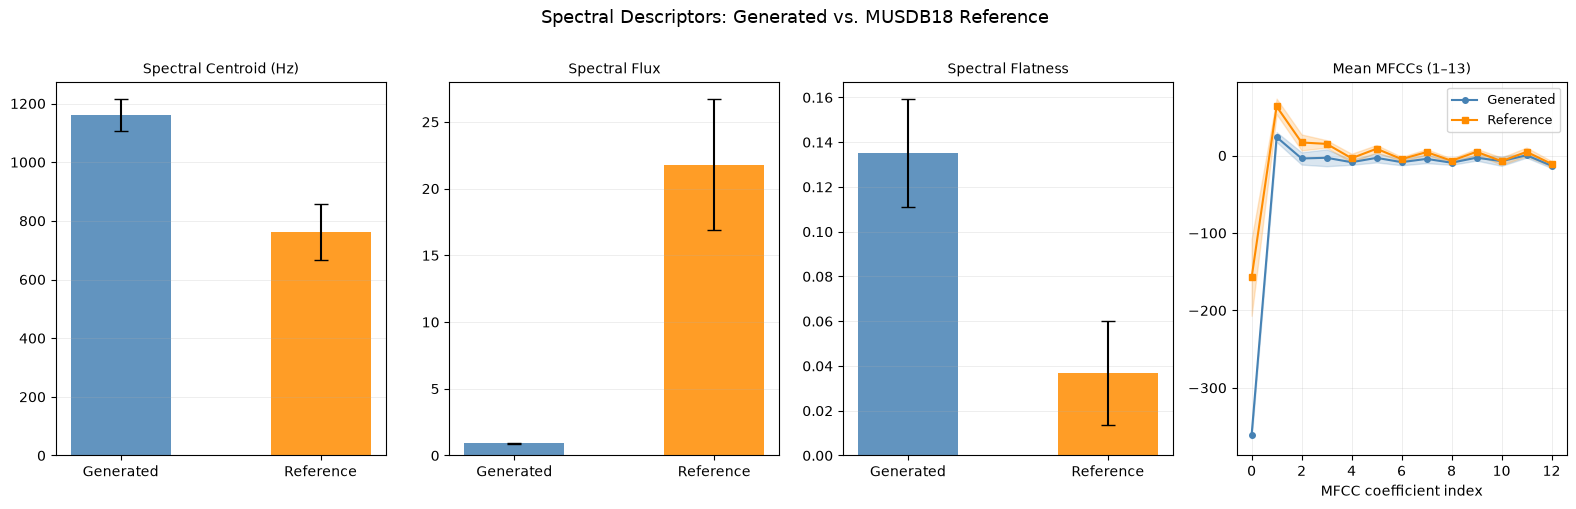

Saved: ../musdb18/output/figures/spectral_descriptors_comparison.png


In [7]:
fig, axes = plt.subplots(1, 4, figsize=(16, 5))

bar_width = 0.35
colors    = {'Generated': 'steelblue', 'Reference': 'darkorange'}

for ax, m, label in zip(axes[:3], metrics, labels):
    gm, gs = gen_stats[m]
    rm, rs = ref_stats[m]
    x = np.arange(2)
    bars = ax.bar(x, [gm, rm], width=0.5,
                  color=[colors['Generated'], colors['Reference']], alpha=0.85)
    ax.errorbar(x, [gm, rm], yerr=[gs, rs], fmt='none',
                color='black', capsize=5, linewidth=1.5)
    ax.set_xticks(x)
    ax.set_xticklabels(['Generated', 'Reference'], fontsize=10)
    ax.set_title(label, fontsize=10)
    ax.grid(True, axis='y', alpha=0.3)

ax_mfcc = axes[3]
coeff_idx = np.arange(N_MFCC)
ax_mfcc.plot(coeff_idx, gen_mfcc.mean(0), 'o-', color='steelblue',
             label='Generated', linewidth=1.5, markersize=4)
ax_mfcc.fill_between(coeff_idx,
                     gen_mfcc.mean(0) - gen_mfcc.std(0),
                     gen_mfcc.mean(0) + gen_mfcc.std(0),
                     alpha=0.2, color='steelblue')
ax_mfcc.plot(coeff_idx, ref_mfcc.mean(0), 's-', color='darkorange',
             label='Reference', linewidth=1.5, markersize=4)
ax_mfcc.fill_between(coeff_idx,
                     ref_mfcc.mean(0) - ref_mfcc.std(0),
                     ref_mfcc.mean(0) + ref_mfcc.std(0),
                     alpha=0.2, color='darkorange')
ax_mfcc.set_xlabel('MFCC coefficient index', fontsize=10)
ax_mfcc.set_title('Mean MFCCs (1–13)', fontsize=10)
ax_mfcc.legend(fontsize=9)
ax_mfcc.grid(True, alpha=0.3)

plt.suptitle('Spectral Descriptors: Generated vs. MUSDB18 Reference',
             fontsize=13, y=1.01)
plt.tight_layout()
out_path = FIGURES_DIR / 'spectral_descriptors_comparison.png'
plt.savefig(out_path, dpi=180, bbox_inches='tight')
plt.show()
print('Saved:', out_path)